In [3]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx

from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import FancyArrowPatch


from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

N, A = 12, 2

NUM_EPISODES = 5000
EP_LEN = 7

BLACK_ACTION = 0
GRAY_ACTION = 1

BLACK = (0 / 255, 0 / 255, 0 / 255)
GRAY = (175 / 255, 171 / 255, 171 / 255)

SAFETY_BETA = 20.0

NODE1 = 0
NODE2 = 1
NODE3 = 2
NODE4 = 3
NODE5 = 4
NODE6 = 5
NODE7 = 6
NODE8 = 7
NODE9 = 8
NODE10 = 9
NODE11 = 10
NODE12 = 11

import numpy as np
from collections import Counter


# ============================================================
# Sparse structured MDP
#
# Action 0 = black
# Action 1 = gray
#
# Short route:
#     1 -> 2/8 -> 3
#
# Longer safe route:
#     1 -> 9/10 -> 11/12 -> 3
#
# Nodes 2 and 8 have moderately higher risk.
#
# Every state/action still has exactly TWO outcomes.
# ============================================================
def build_mdp_and_risk(rng=None):

    P = np.zeros((A, N, N), dtype=float)

    def set_pair(a, s, t1, p1, t2, p2):

        if t1 == s or t2 == s:
            raise ValueError(
                f"Self loop detected: action {a}, node {s + 1}"
            )

        if t1 == t2:
            raise ValueError(
                f"Two outcomes must differ: action {a}, node {s + 1}"
            )

        P[a, s] = 0.0

        P[a, s, t1] = float(p1)
        P[a, s, t2] = float(p2)

        P[a, s] /= P[a, s].sum()


    # ============================================================
    # NODE 1
    #
    # Black action:
    # short but risky route through nodes 2 and 8
    #
    # Gray action:
    # longer and safer routes through nodes 9 and 10
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE1,
        NODE2, 0.55,
        NODE8, 0.45
    )

    set_pair(
        GRAY_ACTION,
        NODE1,
        NODE9, 0.35,
        NODE10, 0.65
    )


    # ============================================================
    # NODES 2 AND 8
    #
    # Black action rapidly reaches the goal.
    # Gray action allows escape toward the safer region.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE2,
        NODE3, 0.94,
        NODE8, 0.06
    )

    set_pair(
        GRAY_ACTION,
        NODE2,
        NODE4, 0.60,
        NODE10, 0.40
    )


    set_pair(
        BLACK_ACTION,
        NODE8,
        NODE3, 0.94,
        NODE2, 0.06
    )

    set_pair(
        GRAY_ACTION,
        NODE8,
        NODE5, 0.60,
        NODE9, 0.40
    )


    # ============================================================
    # NODE 9
    #
    # Slightly less safe route.
    #
    # Gray action can take the relatively short
    #
    # 1 -> 9 -> 12 -> 3
    #
    # route, or enter the longer safe branch through node 4.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE9,
        NODE2, 0.55,
        NODE4, 0.45
    )

    set_pair(
        GRAY_ACTION,
        NODE9,
        NODE12, 0.40,
        NODE4, 0.60
    )


    # ============================================================
    # NODE 10
    #
    # Main entrance to the longer safe route.
    #
    # 10 -> 4/5 -> 6/7 -> 11/12 -> 3
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE10,
        NODE8, 0.55,
        NODE5, 0.45
    )

    set_pair(
        GRAY_ACTION,
        NODE10,
        NODE4, 0.55,
        NODE5, 0.45
    )


    # ============================================================
    # NODE 4
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE4,
        NODE2, 0.30,
        NODE6, 0.70
    )

    set_pair(
        GRAY_ACTION,
        NODE4,
        NODE6, 0.65,
        NODE7, 0.35
    )


    # ============================================================
    # NODE 5
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE5,
        NODE8, 0.30,
        NODE4, 0.70
    )

    set_pair(
        GRAY_ACTION,
        NODE5,
        NODE7, 0.65,
        NODE6, 0.35
    )


    # ============================================================
    # NODE 6
    #
    # Node 11 is preferred over slightly less safe node 12.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE6,
        NODE2, 0.25,
        NODE7, 0.75
    )

    set_pair(
        GRAY_ACTION,
        NODE6,
        NODE11, 0.75,
        NODE12, 0.25
    )


    # ============================================================
    # NODE 7
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE7,
        NODE8, 0.25,
        NODE6, 0.75
    )

    set_pair(
        GRAY_ACTION,
        NODE7,
        NODE11, 0.75,
        NODE12, 0.25
    )


    # ============================================================
    # NODE 11
    #
    # Safest final-stage node.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE11,
        NODE9, 0.35,
        NODE3, 0.65
    )

    set_pair(
        GRAY_ACTION,
        NODE11,
        NODE3, 0.92,
        NODE12, 0.08
    )


    # ============================================================
    # NODE 12
    #
    # Slightly less safe alternative to node 11.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE12,
        NODE9, 0.55,
        NODE3, 0.45
    )

    set_pair(
        GRAY_ACTION,
        NODE12,
        NODE3, 0.88,
        NODE11, 0.12
    )


    # ============================================================
    # NODE 3
    #
    # Outgoing transitions are important because they make
    # the complete MDP communicating.
    #
    # Planning still terminates when node 3 is reached.
    # ============================================================

    set_pair(
        BLACK_ACTION,
        NODE3,
        NODE1, 0.70,
        NODE2, 0.30
    )

    set_pair(
        GRAY_ACTION,
        NODE3,
        NODE1, 0.70,
        NODE10, 0.30
    )


    # ============================================================
    # NODE RISKS
    #
    # Nodes 2 and 8:
    # clearly risky
    #
    # Nodes 9 and 12:
    # slightly less safe
    #
    # Nodes 10 and 11:
    # safer
    #
    # Nodes 4 to 7:
    # low-risk intermediate states
    # ============================================================

    p_acc = np.array([
        0.0020,   # node 1

        0.0700,   # node 2
        0.0000,   # node 3

        0.0030,   # node 4
        0.0040,   # node 5
        0.0025,   # node 6
        0.0035,   # node 7

        0.0750,   # node 8

        0.0150,   # node 9
        0.0040,   # node 10
        0.0030,   # node 11
        0.0180,   # node 12
    ])


    validate_mdp(P)

    return P, p_acc

def validate_communicating_mdp(
    P,
    start=NODE1,
    goal=NODE3
):

    import networkx as nx

    A_, N_, _ = P.shape

    G_support = nx.DiGraph()

    G_support.add_nodes_from(
        range(N_)
    )


    for a in range(A_):

        for s in range(N_):

            targets = np.flatnonzero(
                P[a, s] > 1e-12
            )

            for sp in targets:

                G_support.add_edge(
                    s,
                    int(sp)
                )


    communicating = nx.is_strongly_connected(
        G_support
    )


    print(
        "Communicating MDP:",
        communicating
    )


    relevant_nodes = []

    for s in range(N_):

        from_start = nx.has_path(
            G_support,
            start,
            s
        )

        to_goal = nx.has_path(
            G_support,
            s,
            goal
        )

        if from_start and to_goal:

            relevant_nodes.append(
                s + 1
            )


    print(
        "Nodes lying on some start-to-goal route:",
        relevant_nodes
    )


    if not communicating:

        raise ValueError(
            "The MDP is not communicating."
        )

    if len(relevant_nodes) != N_:

        raise ValueError(
            "Some nodes cannot participate in planning from start to goal."
        )


    return G_support

def validate_mdp(P):
    A, N, _ = P.shape

    for a in range(A):
        for s in range(N):
            nz = np.flatnonzero(P[a, s] > 1e-12)

            assert len(nz) == 2, f"Action {a}, node {s + 1} has {len(nz)} outcomes"
            assert s not in nz, f"Action {a}, node {s + 1} has a self loop"
            assert np.isclose(P[a, s].sum(), 1.0), f"Action {a}, node {s + 1} row does not sum to 1"



def print_main_transitions(P):
    def show(a, s):
        nz = np.flatnonzero(P[a, s] > 1e-12)
        targets = [(int(t + 1), float(P[a, s, t])) for t in nz]
        action_name = "black" if a == BLACK_ACTION else "gray"



def edges_from_mdp(P, prob_threshold=0.02):
    A, N, _ = P.shape

    G = nx.MultiDiGraph()
    G.add_nodes_from(range(N))

    for a in range(A):
        for s in range(N):
            for sp in range(N):
                p = float(P[a, s, sp])

                if p >= prob_threshold:
                    G.add_edge(
                        s,
                        sp,
                        weight=p,
                        action=a,
                    )

    return G


def build_sampler(P):
    A, N, _ = P.shape

    tables = {
        (a, s): (np.arange(N, dtype=int), P[a, s].astype(float))
        for a in range(A)
        for s in range(N)
    }

    def step_next(rng, s, a):
        targets, probs = tables[(a, s)]
        probs = probs / probs.sum()
        return int(rng.choice(targets, p=probs))

    return step_next


def generate_episodes(
    P,
    p_acc,
    num_episodes=1000,
    ep_len=3,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    step = build_sampler(P)

    episodes = []
    episode_actions = []

    safety = np.zeros(
        num_episodes,
        dtype=float
    )

    accident = np.zeros(
        num_episodes,
        dtype=float
    )


    for m in range(num_episodes):

        s = int(
            rng.integers(0, N)
        )

        traj = [s]
        acts = []


        for _ in range(ep_len):

            a = int(
                rng.integers(0, A)
            )

            acts.append(a)

            s = step(
                rng,
                s,
                a
            )

            traj.append(s)


        episodes.append(traj)
        episode_actions.append(acts)


        # ====================================================
        # Accumulated safety
        #
        # S = Π_t [1 - p_risk(s_t)]
        #
        # Repeated visits are counted repeatedly.
        # ====================================================

        nodes = np.asarray(
            traj,
            dtype=int
        )

        safety[m] = np.prod(
            1.0 - p_acc[nodes]
        )

        accident[m] = (
            1.0 - safety[m]
        )


    # ========================================================
    # Ordinary binary index-cell activation
    # ========================================================

    epi_Q = np.zeros(
        (num_episodes, N),
        dtype=float
    )

    for m, traj in enumerate(episodes):

        epi_Q[
            m,
            np.unique(traj)
        ] = 1.0


    return (
        episodes,
        episode_actions,
        epi_Q,
        safety,
        accident
    )

def nonlinear_safety_activation(
    safety,
    beta=25.0
):
    """
    Smooth nonlinear safety gating.

    S = 1:
        weight = 1

    Lower S:
        weight gradually decreases.

    w(S) = exp[-beta * (1-S)]
    """

    safety = np.asarray(
        safety,
        dtype=float
    )

    return np.exp(
        -beta * (1.0 - safety)
    )


def episode_has_current_before_goal(traj, current, goal):
    for i, node_i in enumerate(traj[:-1]):
        if node_i != current:
            continue

        for node_j in traj[i + 1:]:
            if node_j == goal:
                return True

    return False


def ena_action_vote(
    episodes,
    episode_actions,
    current,
    goal,
    P,
    episode_safety=None,
    safety_beta=None,
):
    """
    ENA action vote.

    Before gating:
        every activated index neuron contributes weight 1.

    After safety gating:
        contribution =
        exp[-beta * (1 - episode_safety)]

    Only the action actually taken at the queried
    current node contributes to the vote.
    """

    votes = np.zeros(
        A,
        dtype=float
    )

    activated_count = 0


    for m, (traj, acts) in enumerate(
        zip(
            episodes,
            episode_actions
        )
    ):

        # ----------------------------------------------------
        # Find current node followed later by the goal
        # ----------------------------------------------------

        for i in range(
            len(traj) - 1
        ):

            if traj[i] != current:
                continue

            if goal not in traj[i + 1:]:
                continue


            # ------------------------------------------------
            # Episode/index activation strength
            # ------------------------------------------------

            if safety_beta is None:

                # Before safety gating:
                # all index neurons fire equally strongly.

                weight = 1.0

            else:

                S = float(
                    episode_safety[m]
                )

                weight = float(
                    np.exp(
                        -safety_beta
                        *
                        (1.0 - S)
                    )
                )


            # ------------------------------------------------
            # Vote only for the action taken at current state
            # ------------------------------------------------

            a = int(
                acts[i]
            )

            votes[a] += weight

            activated_count += 1

            # One episode contributes once
            break


    applicable = np.array([
        np.count_nonzero(
            P[a, current] > 1e-12
        ) > 0
        for a in range(A)
    ])


    gated_votes = votes.copy()

    gated_votes[
        ~applicable
    ] = -np.inf


    if np.all(
        gated_votes == -np.inf
    ):

        selected_action = 0

    elif np.max(
        gated_votes
    ) <= 0:

        selected_action = int(
            np.flatnonzero(
                applicable
            )[0]
        )

    else:

        selected_action = int(
            np.argmax(
                gated_votes
            )
        )


    return (
        selected_action,
        votes,
        gated_votes,
        activated_count
    )

def build_ena_policy(
    P,
    episodes,
    episode_actions,
    goal,
    episode_safety=None,
    safety_beta=None,
):

    policy = np.zeros(
        N,
        dtype=int
    )

    all_votes = np.zeros(
        (N, A),
        dtype=float
    )

    activated_counts = np.zeros(
        N,
        dtype=int
    )


    for s in range(N):

        (
            action,
            votes,
            gated_votes,
            activated_count
        ) = ena_action_vote(
            episodes=episodes,
            episode_actions=episode_actions,
            current=s,
            goal=goal,
            P=P,
            episode_safety=episode_safety,
            safety_beta=safety_beta,
        )

        policy[s] = action

        all_votes[s] = votes

        activated_counts[s] = (
            activated_count
        )


    return (
        policy,
        all_votes,
        activated_counts
    )

def sample_path_from_policy(
    P,
    policy,
    start,
    goal,
    rng,
    max_steps=20,
):

    s = start

    path = [s]

    chosen_actions = []


    for _ in range(max_steps):

        if s == goal:
            break

        a = int(
            policy[s]
        )

        chosen_actions.append(a)

        s = int(
            rng.choice(
                np.arange(N),
                p=P[a, s]
            )
        )

        path.append(s)


        if s == goal:
            break


    success = (
        path[-1] == goal
    )


    return (
        path,
        chosen_actions,
        success
    )



def action_name(a):
    return "black" if int(a) == BLACK_ACTION else "gray"

def plan_and_print_top4(
    P,
    episodes,
    episode_actions,
    episode_safety,
    start=NODE1,
    goal=NODE3,
    num_trials=5000,
    max_steps=20,
    seed=123,
    safety_beta=None,
    title="Planning",
):

    (
        policy,
        all_votes,
        activated_counts
    ) = build_ena_policy(
        P=P,
        episodes=episodes,
        episode_actions=episode_actions,
        goal=goal,
        episode_safety=episode_safety,
        safety_beta=safety_beta,
    )


    rng = np.random.default_rng(seed)

    path_counter = Counter()


    # ========================================================
    # Planning trials
    # ========================================================

    for _ in range(num_trials):

        (
            path,
            chosen_actions,
            success
        ) = sample_path_from_policy(
            P=P,
            policy=policy,
            start=start,
            goal=goal,
            rng=rng,
            max_steps=max_steps,
        )


        if success:

            path_user_numbers = tuple(
                n + 1
                for n in path
            )

            path_counter[
                path_user_numbers
            ] += 1


    # ========================================================
    # Print summary
    # ========================================================

    print(
        "\n"
        + "=" * 65
    )

    print(title)

    print(
        "=" * 65
    )


    print(
        f"Vote at node {start + 1}: "
        f"black = {all_votes[start, BLACK_ACTION]:.3f}, "
        f"gray = {all_votes[start, GRAY_ACTION]:.3f}"
    )


    first_action = int(
        policy[start]
    )

    print(
        f"Selected action at node {start + 1}: "
        f"{action_name(first_action)}"
    )


    # ========================================================
    # Top 4 paths
    # ========================================================

    print("\nTop 4 successful paths:")

    for path, count in path_counter.most_common(4):

        path_str = " -> ".join(
            map(str, path)
        )

        frequency = (
            100.0
            *
            count
            /
            num_trials
        )

        print(
            f"{path_str:<35} "
            f"count = {count:<5d} "
            f"({frequency:.1f}%)"
        )


    # ========================================================
    # Policy at each node
    # ========================================================

    print("\nAction policy:")

    for s in range(N):

        if s == goal:
            continue

        selected = int(
            policy[s]
        )

        print(
            f"Node {s + 1:2d}: "
            f"black = {all_votes[s, BLACK_ACTION]:8.3f}, "
            f"gray = {all_votes[s, GRAY_ACTION]:8.3f} "
            f"-> {action_name(selected)}"
        )


    return (
        path_counter,
        policy,
        all_votes
    )


def inspect_ena_vote_at_state(
    P,
    episodes,
    episode_actions,
    current=NODE1,
    goal=NODE3,
    title="ENA vote",
):
    rng = np.random.default_rng(BASE_SEED + 2024)

    a, votes, gated_votes, activated_count = ena_action_vote(
        episodes=episodes,
        episode_actions=episode_actions,
        current=current,
        goal=goal,
        P=P,
        rng=rng,
        fallback_mode="random",
    )


def tsne2d_positions(
    epi_Q,
    epi_Q_gated,
    random_state=42,
    perplexity=6,
    learning_rate=100,
):
    pca_init = PCA(
        n_components=2,
        random_state=random_state,
    ).fit_transform(epi_Q.T)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        early_exaggeration=1.0,
        init=pca_init,
        random_state=random_state,
    )

    Xo = tsne.fit_transform(epi_Q.T)

    tsne_g = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        early_exaggeration=2.0,
        init=pca_init,
        random_state=random_state,
    )

    Xg = tsne_g.fit_transform(epi_Q_gated.T)

    pos_orig = {
        i: (float(Xo[i, 0]), float(Xo[i, 1]))
        for i in range(Xo.shape[0])
    }

    pos_gated = {
        i: (float(Xg[i, 0]), float(Xg[i, 1]))
        for i in range(Xg.shape[0])
    }

    return pos_orig, pos_gated


def prob_to_width(p, w_min=0.8, w_max=4.0, gamma=0.75):
    p = float(np.clip(p, 0.0, 1.0))
    return w_min + (w_max - w_min) * (p ** gamma)


def draw_curved_arrow(ax, pos, u, v, color, width, rad, arrow_size=24):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=arrow_size,
        linewidth=width,
        color=color,
        alpha=0.95,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=20,
        shrinkB=13,
        zorder=3,
    )

    ax.add_patch(arrow)


def draw_graph_2d(
    ax,
    G,
    node_risk,
    pos2d,
    lw_min=0.8,
    lw_max=4.0,
    prob_gamma=0.75,
):
    node_size = 1000

    cmap_nodes = LinearSegmentedColormap.from_list("white_red", ["white", "red"])
    risk_norm = Normalize(vmin=0.001, vmax=0.01)
    node_cols = [cmap_nodes(risk_norm(node_risk[i])) for i in range(N)]

    for u, v, key, data in G.edges(keys=True, data=True):
        a = int(data["action"])
        p = float(data["weight"])

        color = BLACK if a == BLACK_ACTION else GRAY
        width = prob_to_width(p, lw_min, lw_max, prob_gamma)

        if a == BLACK_ACTION:
            rad = 0.24
        else:
            rad = -0.24

        draw_curved_arrow(
            ax=ax,
            pos=pos2d,
            u=u,
            v=v,
            color=color,
            width=width,
            rad=rad,
            arrow_size=26,
        )

    labels = nx.draw_networkx_labels(
        G,
        pos2d,
        labels={i: str(i + 1) for i in range(N)},
        font_size=20,
        ax=ax,
    )

    node_artist = nx.draw_networkx_nodes(
        G,
        pos2d,
        node_size=node_size,
        node_color=node_cols,
        edgecolors="black",
        linewidths=1.2,
        ax=ax,
    )

    node_artist.set_zorder(3)

    for text in labels.values():
        text.set_zorder(4)
        text.set_path_effects([
            pe.withStroke(linewidth=3, foreground="white")
        ])

    ax.set_aspect("equal")
    ax.margins(0.20)
    ax.axis("off")

# ============================================================
# MAIN SIMULATION
# ============================================================

BASE_SEED = 58

NUM_EPISODES = 5000
EP_LEN = 7

SAFETY_BETA = 20.0

NUM_PLANNING_TRIALS = 5000
MAX_PLANNING_STEPS = 20


# ============================================================
# Build MDP
# ============================================================

rng = np.random.default_rng(BASE_SEED)

P, p_acc = build_mdp_and_risk(rng)


# ============================================================
# Verify communicating MDP
# ============================================================

G_support = validate_communicating_mdp(
    P,
    start=NODE1,
    goal=NODE3
)


# ============================================================
# Build graph for plotting
# ============================================================

G = edges_from_mdp(
    P,
    prob_threshold=0.02
)


# ============================================================
# Generate episodes
#
# IMPORTANT:
#
# Use NUM_EPISODES and EP_LEN here.
# Do not hard-code 1000 and 3.
# ============================================================

(
    episodes,
    episode_actions,
    epi_Q,
    epi_safety,
    epi_accident,
) = generate_episodes(
    P=P,
    p_acc=p_acc,
    num_episodes=NUM_EPISODES,
    ep_len=EP_LEN,
    rng=rng,
)


# ============================================================
# Print episode-safety statistics
# ============================================================

print("\nEpisode safety statistics")

print(
    f"minimum = {epi_safety.min():.4f}"
)

print(
    f"mean    = {epi_safety.mean():.4f}"
)

print(
    f"median  = {np.median(epi_safety):.4f}"
)

print(
    f"maximum = {epi_safety.max():.4f}"
)


# ============================================================
# BEFORE SAFETY GATING
#
# Every activated index neuron contributes exactly 1.
# ============================================================

(
    paths_before,
    policy_before,
    votes_before,
) = plan_and_print_top4(
    P=P,
    episodes=episodes,
    episode_actions=episode_actions,
    episode_safety=epi_safety,

    start=NODE1,
    goal=NODE3,

    num_trials=NUM_PLANNING_TRIALS,
    max_steps=MAX_PLANNING_STEPS,

    seed=123,

    safety_beta=None,

    title="BEFORE SAFETY GATING",
)


# ============================================================
# AFTER SAFETY GATING
#
# Index neuron activation:
#
#     w = exp[-beta * (1 - safety)]
#
# ============================================================

(
    paths_after,
    policy_after,
    votes_after,
) = plan_and_print_top4(
    P=P,
    episodes=episodes,
    episode_actions=episode_actions,
    episode_safety=epi_safety,

    start=NODE1,
    goal=NODE3,

    num_trials=NUM_PLANNING_TRIALS,
    max_steps=MAX_PLANNING_STEPS,

    seed=123,

    safety_beta=SAFETY_BETA,

    title="AFTER SAFETY GATING",
)

Communicating MDP: True
Nodes lying on some start-to-goal route: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Episode safety statistics
minimum = 0.6353
mean    = 0.8846
median  = 0.8951
maximum = 0.9836

BEFORE SAFETY GATING
Vote at node 1: black = 835.000, gray = 489.000
Selected action at node 1: black

Top 4 successful paths:
1 -> 2 -> 3                         count = 2620  (52.4%)
1 -> 8 -> 3                         count = 2087  (41.7%)
1 -> 2 -> 8 -> 3                    count = 148   (3.0%)
1 -> 8 -> 2 -> 3                    count = 126   (2.5%)

Action policy:
Node  1: black =  835.000, gray =  489.000 -> black
Node  2: black = 1246.000, gray =  492.000 -> black
Node  4: black =  806.000, gray =  781.000 -> black
Node  5: black =  437.000, gray =  522.000 -> gray
Node  6: black =  745.000, gray = 1117.000 -> gray
Node  7: black =  592.000, gray =  869.000 -> gray
Node  8: black =  954.000, gray =  429.000 -> black
Node  9: black =  461.000, gray =  546.000 -> gray
Node 10: black

In [4]:
%pip install ipympl -q
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

class DraggableMDPGraph:
    """
    Interactive draggable MDP graph.

    Node color:
        local node safety = 1 - p_risk

        lower safety  -> red
        higher safety -> white

    Edge color:
        action 0 -> black
        action 1 -> gray

    Edge width:
        transition probability

    The node positions can be changed by clicking and dragging.
    """

    def __init__(
        self,
        G,
        pos,
        node_risk,
        black_action=0,
        gray_action=1,
        black=(0, 0, 0),
        gray=(175/255, 171/255, 171/255),
        node_size=850,
        node_linewidth=2.2,
        font_size=16,
        lw_min=1.0,
        lw_max=3.0,
        prob_gamma=0.75,
        curve=0.16,
        arrow_size=18,
        figsize=(8.5, 6.2),
        dpi=120,
        show_colorbar=True,
    ):

        # ============================================================
        # Store graph and positions
        # ============================================================

        self.G = G
        self.nodes = list(G.nodes())

        self.pos = {
            n: np.array(pos[n], dtype=float)
            for n in self.nodes
        }

        # ============================================================
        # Node risk and safety
        # ============================================================

        self.node_risk = np.asarray(
            node_risk,
            dtype=float
        )

        if len(self.node_risk) != len(self.nodes):
            raise ValueError(
                "node_risk must contain one risk value for every node."
            )

        # Local node safety
        #
        # safety_i = 1 - p_risk_i

        self.node_safety = (
            1.0 - self.node_risk
        )

        # ============================================================
        # Plotting parameters
        # ============================================================

        self.black_action = black_action
        self.gray_action = gray_action

        self.black = black
        self.gray = gray

        self.node_size = node_size
        self.node_linewidth = node_linewidth
        self.font_size = font_size

        self.lw_min = lw_min
        self.lw_max = lw_max
        self.prob_gamma = prob_gamma

        self.curve = curve
        self.arrow_size = arrow_size

        self.dragging = None

        # ============================================================
        # Figure
        # ============================================================

        self.fig, self.ax = plt.subplots(
            figsize=figsize,
            dpi=dpi
        )

        self.ax.set_aspect("equal")
        self.ax.axis("off")

        # ============================================================
        # Node colormap
        #
        # low safety  -> red
        # high safety -> white
        # ============================================================

        self.cmap_nodes = LinearSegmentedColormap.from_list(
            "node_safety",
            [
                (0.75, 0.10, 0.10),
                (1.00, 1.00, 1.00),
            ]
        )

        safety_min = float(
            np.min(self.node_safety)
        )

        safety_max = float(
            np.max(self.node_safety)
        )

        # Prevent degenerate normalization
        if np.isclose(safety_min, safety_max):
            safety_min -= 1e-6
            safety_max += 1e-6

        self.safety_norm = Normalize(
            vmin=safety_min,
            vmax=safety_max
        )

        # ============================================================
        # Draw edges first
        # ============================================================

        self.edge_artists = []
        self.edge_meta = []

        for u, v, key, data in self.G.edges(
            keys=True,
            data=True
        ):

            action = int(data["action"])
            p = float(data["weight"])

            # --------------------------------------------------------
            # Action color and curvature
            # --------------------------------------------------------

            if action == self.black_action:

                color = self.black
                rad = self.curve

            elif action == self.gray_action:

                color = self.gray
                rad = -self.curve

            else:

                color = self.black
                rad = 0.0

            # --------------------------------------------------------
            # Probability controls arrow width
            # --------------------------------------------------------

            width = self._prob_to_width(p)

            # --------------------------------------------------------
            # Arrow
            # --------------------------------------------------------

            arrow = FancyArrowPatch(
                self.pos[u],
                self.pos[v],

                arrowstyle="-|>",
                mutation_scale=self.arrow_size,

                linewidth=width,
                color=color,
                alpha=0.98,

                connectionstyle=f"arc3,rad={rad}",

                shrinkA=20,
                shrinkB=20,

                zorder=1,
            )

            self.ax.add_patch(arrow)

            self.edge_artists.append(arrow)

            self.edge_meta.append(
                {
                    "u": u,
                    "v": v,
                    "action": action,
                    "probability": p,
                }
            )

        # ============================================================
        # Draw nodes
        # ============================================================

        xy = np.array([
            self.pos[n]
            for n in self.nodes
        ])

        node_colors = [
            self.cmap_nodes(
                self.safety_norm(
                    self.node_safety[n]
                )
            )
            for n in self.nodes
        ]

        self.node_artist = self.ax.scatter(
            xy[:, 0],
            xy[:, 1],

            s=self.node_size,

            c=node_colors,

            edgecolors="black",
            linewidths=self.node_linewidth,

            zorder=3,
        )

        # ============================================================
        # Node labels
        # ============================================================

        self.labels = {}

        for n in self.nodes:

            x, y = self.pos[n]

            self.labels[n] = self.ax.text(
                x,
                y,

                str(n + 1),

                ha="center",
                va="center",

                fontsize=self.font_size,
                color="black",

                zorder=4,
            )

        # ============================================================
        # Colorbar
        # ============================================================

        if show_colorbar:

            sm = ScalarMappable(
                norm=self.safety_norm,
                cmap=self.cmap_nodes
            )

            sm.set_array([])

            self.cbar = self.fig.colorbar(
                sm,
                ax=self.ax,
                fraction=0.035,
                pad=0.02
            )

            self.cbar.set_label(
                r"Node safety $1-p_{\mathrm{risk}}$",
                fontsize=11
            )

            self.cbar.ax.tick_params(
                labelsize=9
            )

        # ============================================================
        # Set plot limits
        # ============================================================

        self._set_limits()

        # ============================================================
        # Connect mouse events
        # ============================================================

        self.cid_press = self.fig.canvas.mpl_connect(
            "button_press_event",
            self._on_press
        )

        self.cid_motion = self.fig.canvas.mpl_connect(
            "motion_notify_event",
            self._on_motion
        )

        self.cid_release = self.fig.canvas.mpl_connect(
            "button_release_event",
            self._on_release
        )

        self.fig.canvas.draw_idle()


    # ================================================================
    # Convert transition probability to arrow width
    # ================================================================

    def _prob_to_width(self, p):

        p = float(
            np.clip(
                p,
                0.0,
                1.0
            )
        )

        return (
            self.lw_min
            +
            (
                self.lw_max
                -
                self.lw_min
            )
            *
            (
                p ** self.prob_gamma
            )
        )


    # ================================================================
    # Find node nearest to mouse click
    # ================================================================

    def _nearest_node(
        self,
        event,
        max_pixel_distance=30
    ):

        if event.inaxes != self.ax:
            return None

        if event.x is None or event.y is None:
            return None

        mouse = np.array(
            [
                event.x,
                event.y
            ],
            dtype=float
        )

        best_node = None
        best_dist = np.inf

        for n in self.nodes:

            pixel_xy = self.ax.transData.transform(
                self.pos[n]
            )

            dist = np.linalg.norm(
                pixel_xy - mouse
            )

            if dist < best_dist:

                best_node = n
                best_dist = dist

        if best_dist <= max_pixel_distance:
            return best_node

        return None


    # ================================================================
    # Mouse pressed
    # ================================================================

    def _on_press(self, event):

        if event.button != 1:
            return

        self.dragging = self._nearest_node(
            event
        )


    # ================================================================
    # Mouse moving
    # ================================================================

    def _on_motion(self, event):

        if self.dragging is None:
            return

        if event.inaxes != self.ax:
            return

        if (
            event.xdata is None
            or event.ydata is None
        ):
            return

        n = self.dragging

        # ------------------------------------------------------------
        # Update node position
        # ------------------------------------------------------------

        self.pos[n] = np.array(
            [
                event.xdata,
                event.ydata
            ],
            dtype=float
        )

        # ------------------------------------------------------------
        # Update all node coordinates
        # ------------------------------------------------------------

        xy = np.array([
            self.pos[k]
            for k in self.nodes
        ])

        self.node_artist.set_offsets(
            xy
        )

        # ------------------------------------------------------------
        # Update label
        # ------------------------------------------------------------

        self.labels[n].set_position(
            self.pos[n]
        )

        # ------------------------------------------------------------
        # Update every edge touching this node
        # ------------------------------------------------------------

        for arrow, meta in zip(
            self.edge_artists,
            self.edge_meta
        ):

            u = meta["u"]
            v = meta["v"]

            if u == n or v == n:

                arrow.set_positions(
                    self.pos[u],
                    self.pos[v]
                )

        self.fig.canvas.draw_idle()


    # ================================================================
    # Mouse released
    # ================================================================

    def _on_release(self, event):

        self.dragging = None


    # ================================================================
    # Plot limits
    # ================================================================

    def _set_limits(
        self,
        pad=0.20
    ):

        xy = np.array([
            self.pos[n]
            for n in self.nodes
        ])

        xmin, ymin = xy.min(axis=0)
        xmax, ymax = xy.max(axis=0)

        dx = max(
            xmax - xmin,
            1.0
        )

        dy = max(
            ymax - ymin,
            1.0
        )

        self.ax.set_xlim(
            xmin - pad * dx,
            xmax + pad * dx
        )

        self.ax.set_ylim(
            ymin - pad * dy,
            ymax + pad * dy
        )


    # ================================================================
    # Return current node positions
    # ================================================================

    def get_positions(
        self,
        one_indexed=False
    ):

        if one_indexed:

            return {
                int(n + 1): (
                    float(self.pos[n][0]),
                    float(self.pos[n][1])
                )
                for n in self.nodes
            }

        return {
            int(n): (
                float(self.pos[n][0]),
                float(self.pos[n][1])
            )
            for n in self.nodes
        }


    # ================================================================
    # Print positions in copyable Python format
    # ================================================================

    def print_positions(self):

        print("pos = {")

        for n in self.nodes:

            x, y = self.pos[n]

            print(
                f"    {n}: "
                f"({x:.4f}, {y:.4f}),"
            )

        print("}")


    # ================================================================
    # Update node risks later if needed
    # ================================================================

    def update_node_risk(
        self,
        node_risk
    ):

        self.node_risk = np.asarray(
            node_risk,
            dtype=float
        )

        self.node_safety = (
            1.0 - self.node_risk
        )

        safety_min = float(
            np.min(self.node_safety)
        )

        safety_max = float(
            np.max(self.node_safety)
        )

        if np.isclose(
            safety_min,
            safety_max
        ):
            safety_min -= 1e-6
            safety_max += 1e-6

        self.safety_norm.vmin = safety_min
        self.safety_norm.vmax = safety_max

        node_colors = [
            self.cmap_nodes(
                self.safety_norm(
                    self.node_safety[n]
                )
            )
            for n in self.nodes
        ]

        self.node_artist.set_facecolors(
            node_colors
        )

        if hasattr(
            self,
            "cbar"
        ):
            self.cbar.update_normal(
                ScalarMappable(
                    norm=self.safety_norm,
                    cmap=self.cmap_nodes
                )
            )

        self.fig.canvas.draw_idle()


    # ================================================================
    # Save figure
    # ================================================================

    def save(
        self,
        filename="mdp_layout.png",
        dpi=300
    ):

        self.fig.savefig(
            filename,
            dpi=dpi,
            bbox_inches="tight",
            transparent=False
        )

        print(
            f"Saved to {filename}"
        )

In [6]:
def reference_style_positions():

    return {
        NODE1:  (0.00,  0.00),
        NODE2:  (1.15,  1.10),
        NODE3:  (2.35,  0.05),
        NODE4:  (4.05,  0.40),
        NODE5:  (4.25, -0.75),
        NODE6:  (3.45, -0.65),
        NODE7:  (2.65,  1.35),
        NODE8:  (1.15,  0.35),
        NODE9:  (1.15, -0.55),
        NODE10: (1.15, -1.35),
        NODE11: (2.05, -1.05),
        NODE12: (2.05, -1.75),
    }

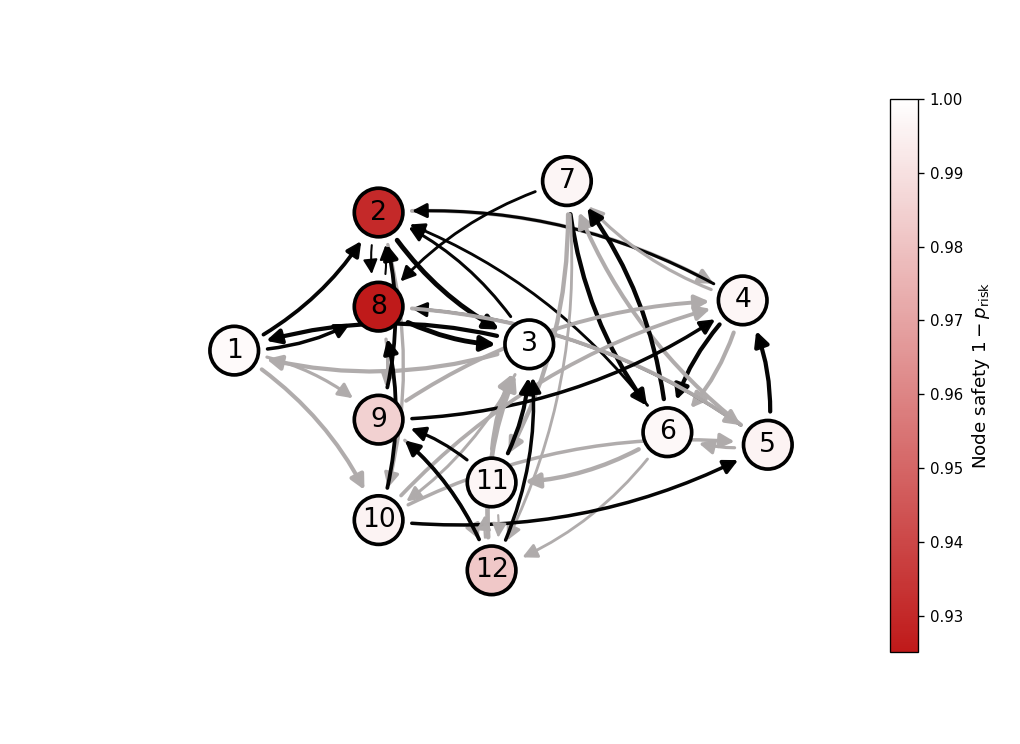

In [7]:
BASE_SEED = 58

rng = np.random.default_rng(BASE_SEED)

P, p_acc = build_mdp_and_risk(rng)

G = edges_from_mdp(
    P,
    prob_threshold=0.02
)

pos0 = reference_style_positions()

editor = DraggableMDPGraph(
    G=G,
    pos=pos0,
    node_risk=p_acc,

    black_action=BLACK_ACTION,
    gray_action=GRAY_ACTION,

    black=BLACK,
    gray=GRAY,

    node_size=850,
    node_linewidth=2.2,
    font_size=16,

    lw_min=1.0,
    lw_max=3.0,

    curve=0.16,

    figsize=(8.5, 6.2),
    dpi=120,
)

plt.show()